In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

print("✅ Libraries imported successfully!")



✅ Libraries imported successfully!


In [6]:
import zipfile
import os

# Replace filename with your uploaded zip file name
zip_path = '/content/student_data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("✅ ZIP file extracted successfully!")

# List extracted files
os.listdir('/content')


✅ ZIP file extracted successfully!


['.config',
 '.ipynb_checkpoints',
 'student_data.zip',
 'Titanic-Dataset.csv',
 'sample_data']

In [9]:
import pandas as pd

df = pd.read_csv('/content/Titanic-Dataset.csv')  # change name if different
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                           

In [11]:
# STEP 5 – Explore the data
print("✅ BASIC DATA INFORMATION\n")

# Show general information
df.info()

# Count of missing values in each column
print("\n🧩 Missing Values:\n", df.isnull().sum())

# Basic numerical statistics (mean, std, etc.)
print("\n📊 Statistical Summary:\n", df.describe())

# Show first few rows
print("\n👀 Sample Rows:")
display(df.head())


✅ BASIC DATA INFORMATION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

🧩 Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin   

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
import numpy as np

print("🧹 Handling Missing Values...")

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill numeric columns with their median value
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with their most frequent value (mode)
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("✅ Missing values handled successfully!")

# Verify again
print("\nRemaining nulls in dataset:\n", df.isnull().sum())


🧹 Handling Missing Values...
✅ Missing values handled successfully!

Remaining nulls in dataset:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


/tmp/ipython-input-254060418.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-254060418.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [14]:
from sklearn.preprocessing import LabelEncoder

print("🎯 Encoding Categorical Columns...")

# Identify categorical columns again (in case you changed df)
categorical_cols = df.select_dtypes(exclude=['number']).columns

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ All categorical columns encoded successfully!")
print("\nEncoded columns:", categorical_cols.tolist())

# Show first few rows to confirm
display(df.head())


🎯 Encoding Categorical Columns...
✅ All categorical columns encoded successfully!

Encoded columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,47,2


📊 Visualizing Outliers...


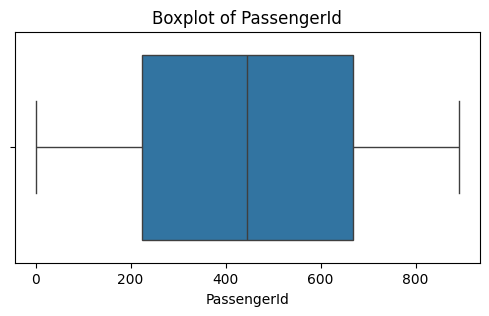

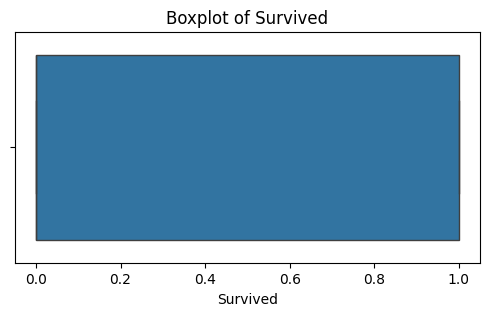

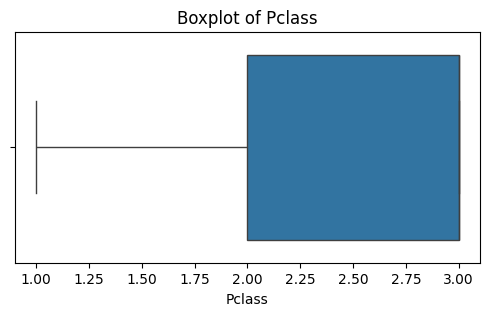

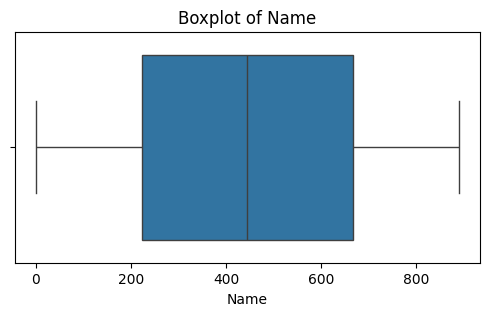

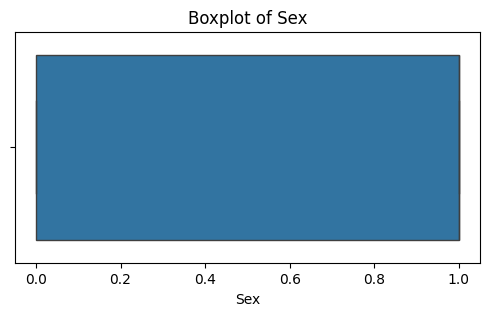

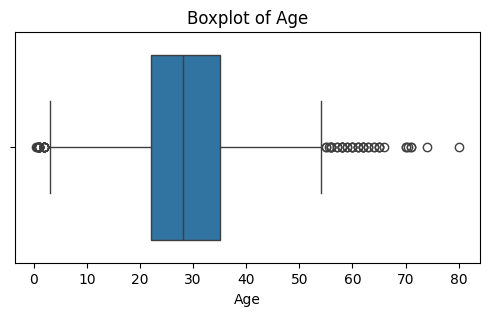

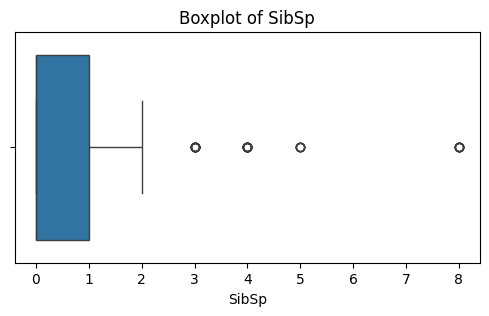

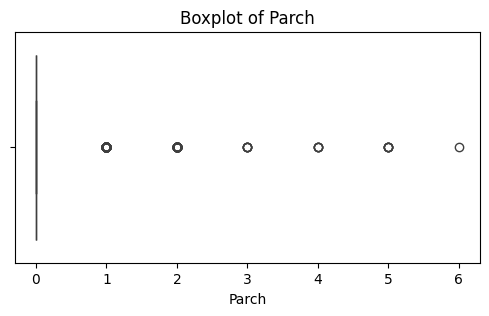

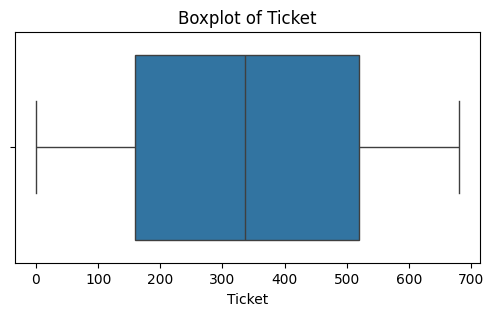

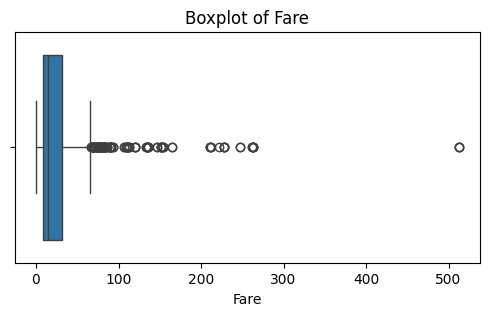

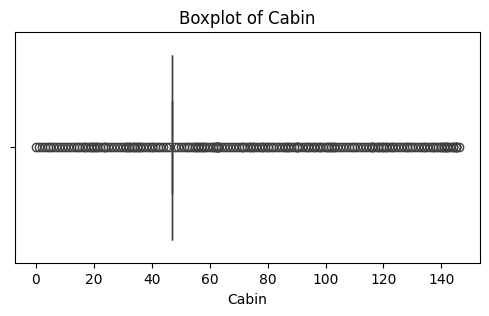

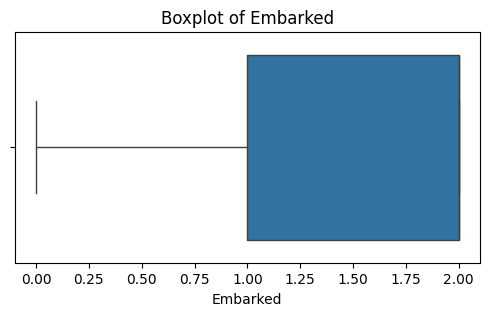

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Visualizing Outliers...")

numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [16]:
print("🧹 Removing Outliers...")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("✅ Outliers handled successfully!")
print("New shape of dataset:", df.shape)


🧹 Removing Outliers...
✅ Outliers handled successfully!
New shape of dataset: (491, 12)


In [17]:
from sklearn.preprocessing import StandardScaler

print("⚙️ Standardizing numeric columns...")

# Select only numeric columns again
numeric_cols = df.select_dtypes(include=['number']).columns

# Create scaler and transform the data
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("✅ Data standardized successfully!")
print("\nScaled numeric columns:", numeric_cols.tolist())

# Show first few rows to confirm
display(df.head())


⚙️ Standardizing numeric columns...
✅ Data standardized successfully!

Scaled numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.705201,-0.571863,0.564718,-1.393931,0.565590,-0.790958,1.828542,0.0,0.924786,-0.595843,0.0,0.548396
2,-1.697461,1.748671,0.564718,-0.420259,-1.768064,-0.290010,-0.432955,0.0,1.764708,-0.500536,0.0,0.548396
4,-1.689720,-0.571863,0.564718,-1.763529,0.565590,0.837125,-0.432955,0.0,0.631389,-0.482887,0.0,0.548396
5,-1.685850,-0.571863,0.564718,0.378550,0.565590,-0.039535,-0.432955,0.0,-0.501931,-0.425237,0.0,-0.868775
9,-1.670370,1.748671,-1.296199,0.465982,-1.768064,-1.792856,1.828542,0.0,-1.324594,2.626354,0.0,-2.285945


In [18]:
# STEP 10 – Save the cleaned dataset
output_path = '/content/cleaned_dataset.csv'

# Save as CSV file
df.to_csv(output_path, index=False)

print("🎉 Cleaned dataset saved successfully as cleaned_dataset.csv!")


🎉 Cleaned dataset saved successfully as cleaned_dataset.csv!
